### Polynomial Regression:
 
 -Polynomial regression is when the relationship between X and Y is curved instead of straight.

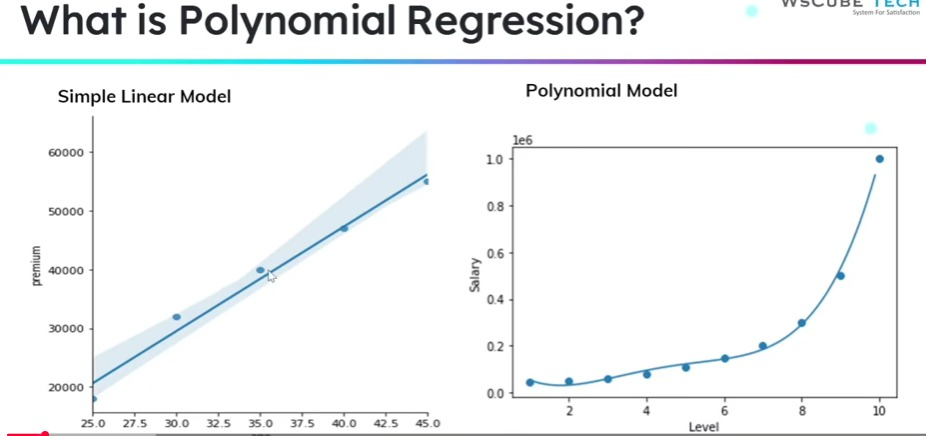

## Advantage

- 1️⃣ Captures curved relationships Works well when data is not straight line.
- 2️⃣ More flexible than linear regression Can fit complex patterns in data.
- 3️⃣ Better accuracy for non-linear problems Gives better predictions when relationship changes with X.
- 4️⃣ Still easy to implement Uses linear regression underneath (just adds powers like x², x³).

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

In [1]:
data = {
    'Position' : ['Business Analyst','Junior Consulatant','Senior Consulatant','Manager','Country Manager','Region Manager','Partner','Senior Partner','C-level','CEO'],
    'Level': [1,2,3,4,5,6,7,8,9,10],
    'Salary': [45000, 50000,60000,80000, 110000, 150000, 200000, 300000, 500000,1000000]
}

print(data)

{'Position': ['Business Analyst', 'Junior Consulatant', 'Senior Consulatant', 'Manager', 'Country Manager', 'Region Manager', 'Partner', 'Senior Partner', 'C-level', 'CEO'], 'Level': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Salary': [45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000]}


In [3]:
df = pd.DataFrame(data)
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consulatant,2,50000
2,Senior Consulatant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [11]:
x = df[['Level']]
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [12]:
y = df[['Salary']]
y

,Salary
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


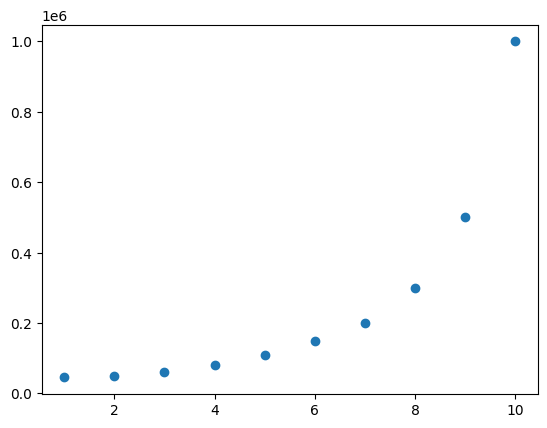

In [6]:
plt.scatter(x,y)

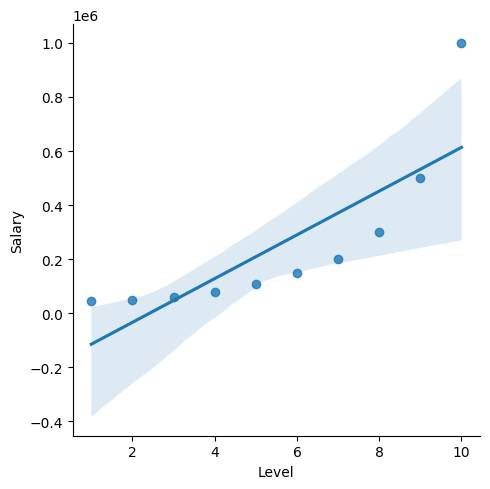

In [7]:
sns.lmplot(x = 'Level',y = 'Salary', data = df)

In [13]:
reg = linear_model.LinearRegression()

In [14]:
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
reg.predict([[6.5]]) # due to the linear Regresion model the output what we are getting is beyond the set threshold

/Users/rahulg/Downloads/python-revision-experiments/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[330378.78787879]])

In [16]:
# hence need to go for polynomial regression

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

In [17]:
x_poly = poly.fit_transform(x)

In [18]:
reg2 = linear_model.LinearRegression()
reg2.fit(x_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
reg2.predict(poly.fit_transform([[6.5]]))

array([[189498.10606061]])

also if you keep on increasing the degree than the model amy get overfit hence need to take precaution will get covered in upcoming session